In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

EDA


In [ ]:
data = pd.read_csv('/content/datafullreal.csv')
data.head()


,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
0,41,Yes,Sales,1,2,Life Sciences,2,Female,94,3,...,4,Single,5993,Yes,11,1,8,1,6,4
1,49,No,Research & Development,8,1,Life Sciences,3,Male,61,2,...,2,Married,5130,No,23,4,10,3,10,7
2,37,Yes,Research & Development,2,2,Other,4,Male,92,2,...,3,Single,2090,Yes,15,2,7,3,0,0
3,33,No,Research & Development,3,4,Life Sciences,4,Female,56,3,...,3,Married,2909,Yes,11,3,8,3,8,7
4,27,No,Research & Development,2,1,Medical,1,Male,40,3,...,2,Married,3468,No,12,4,6,3,2,2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.shape


(1470, 21)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   Department                1470 non-null   object
 3   DistanceFromHome          1470 non-null   int64 
 4   Education                 1470 non-null   int64 
 5   EducationField            1470 non-null   object
 6   EnvironmentSatisfaction   1470 non-null   int64 
 7   Gender                    1470 non-null   object
 8   HourlyRate                1470 non-null   int64 
 9   JobInvolvement            1470 non-null   int64 
 10  JobRole                   1470 non-null   object
 11  JobSatisfaction           1470 non-null   int64 
 12  MaritalStatus             1470 non-null   object
 13  MonthlyIncome             1470 non-null   int64 
 14  OverTime                

In [ ]:
# Identify the data types of columns
column_data_types = data.dtypes

# Count the numerical and categorical columns
numerical_count = 0
categorical_count = 0

for column_name, data_type in column_data_types.items():
    if np.issubdtype(data_type, np.number):
        numerical_count += 1
    else:
        categorical_count += 1

# Print the counts
print(f"There are {numerical_count} Numerical Columns in dataset")
print(f"There are {categorical_count} Categorical Columns in dataset")

There are 14 Numerical Columns in dataset
There are 7 Categorical Columns in dataset


In [ ]:
#Random Sample of dataset with only categorical Feature
data.select_dtypes(include='O').sample(5)

,Attrition,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
669,Yes,Research & Development,Medical,Male,Laboratory Technician,Married,Yes
830,No,Research & Development,Life Sciences,Male,Laboratory Technician,Married,Yes
1229,No,Research & Development,Life Sciences,Female,Manufacturing Director,Married,Yes
823,No,Research & Development,Life Sciences,Female,Research Scientist,Divorced,No
604,No,Research & Development,Life Sciences,Male,Manufacturing Director,Married,No


Inference:

Some of the numerical features are storing discrete numbers (categories labelled) in numbers.
So for better analysis we will replace those labelled numerical values with appropriate categorical values.

In [ ]:
mappings = {
    "EnvironmentSatisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "JobInvolvement": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "JobSatisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "RelationshipSatisfaction": {"Low": 1, "Medium": 2, "High": 3, "Very High": 4},
    "WorkLifeBalance": {"Bad": 1, "Good": 2, "Better": 3, "Best": 4},
    "Education": {"Below College": 1, "College": 2, "Bachelor": 3, "Master": 4, "Doctor": 5}
}

for col, mapping in mappings.items():
    data[col] = data[col].replace(mapping)

In [ ]:
#Random Sample of dataset with only Numerical Feature
data.select_dtypes(np.number).sample(5)

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,PercentSalaryHike,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
1418,38,6,4,1,72,2,3,5321,11,4,10,3,8,3
1155,39,3,2,3,76,2,3,3069,15,4,11,3,10,8
172,36,3,2,4,30,3,2,2088,12,3,13,2,8,7
534,53,7,3,3,59,4,3,14814,19,3,32,3,5,1
1311,18,14,3,2,33,3,3,1514,16,3,0,1,0,0


Data cleaning


In [ ]:
#Checking if There's Any Duplicate Records.
print("Duplicates in Dataset: ",data.duplicated().sum())

Duplicates in Dataset:  0


In [ ]:
#Computing Total No. of Missing Values and the Percentage of Missing Values.
missing_data = data.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})
missing_data["% of Missing Values"] = round((missing_data["Total No. of Missing Values"]/len(data))*100,2)
missing_data

,Total No. of Missing Values,% of Missing Values
Age,0,0.0
Attrition,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EnvironmentSatisfaction,0,0.0
Gender,0,0.0
HourlyRate,0,0.0
JobInvolvement,0,0.0


Inference:
None of the Attribute are having Missing Values.

In [ ]:
# Performing Descriptive Analysis on Categorical Attributes
data.describe(include="O").T

,count,unique,top,freq
Attrition,1470,2,No,1233
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
OverTime,1470,2,No,1054


In [ ]:
#Checking Unique Values of Categorical Attributes.
cat_cols = data.select_dtypes(include="object").columns

for column in cat_cols:
    print('Unique values of ', column, set(data[column]))
    print("-"*121)

Unique values of  Attrition {'No', 'Yes'}
-------------------------------------------------------------------------------------------------------------------------
Unique values of  Department {'Sales', 'Human Resources', 'Research & Development'}
-------------------------------------------------------------------------------------------------------------------------
Unique values of  EducationField {'Marketing', 'Technical Degree', 'Other', 'Life Sciences', 'Medical', 'Human Resources'}
-------------------------------------------------------------------------------------------------------------------------
Unique values of  Gender {'Female', 'Male'}
-------------------------------------------------------------------------------------------------------------------------
Unique values of  JobRole {'Research Director', 'Laboratory Technician', 'Sales Executive', 'Healthcare Representative', 'Research Scientist', 'Manager', 'Sales Representative', 'Human Resources', 'Manufacturing Directo

Target variable


In [ ]:
data.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
0,41,Yes,Sales,1,2,Life Sciences,2,Female,94,3,...,4,Single,5993,Yes,11,1,8,1,6,4
1,49,No,Research & Development,8,1,Life Sciences,3,Male,61,2,...,2,Married,5130,No,23,4,10,3,10,7
2,37,Yes,Research & Development,2,2,Other,4,Male,92,2,...,3,Single,2090,Yes,15,2,7,3,0,0
3,33,No,Research & Development,3,4,Life Sciences,4,Female,56,3,...,3,Married,2909,Yes,11,3,8,3,8,7
4,27,No,Research & Development,2,1,Medical,1,Male,40,3,...,2,Married,3468,No,12,4,6,3,2,2


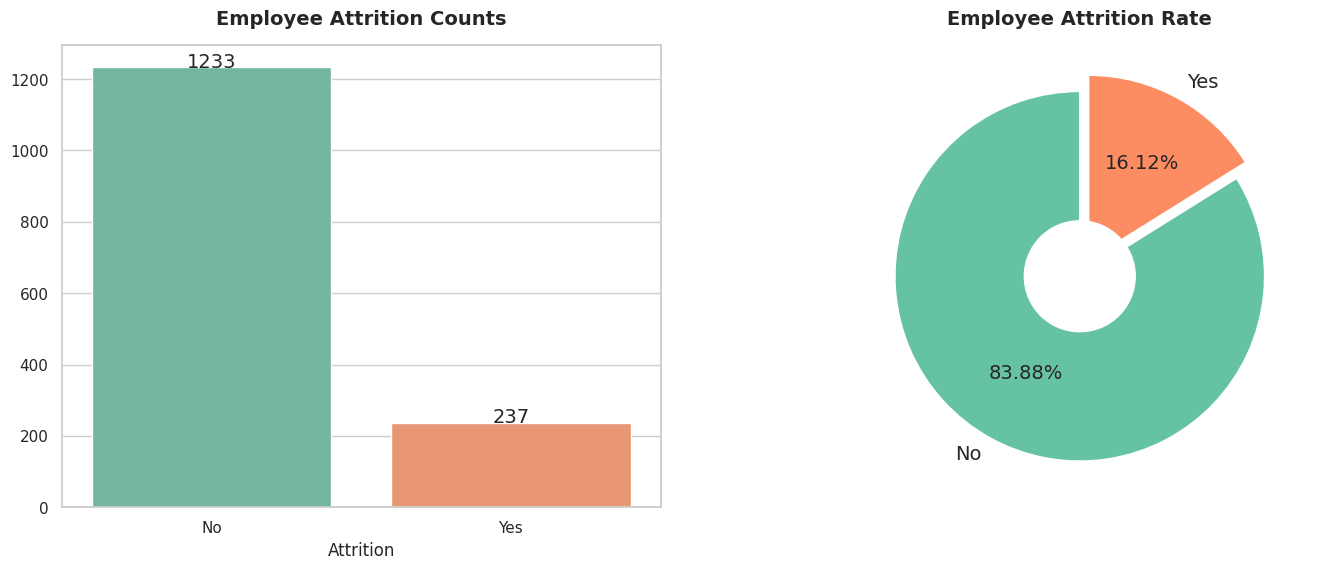

In [ ]:
#Visualization to show Employee Attrition in Counts.
plt.figure(figsize=(17,6))
plt.subplot(1,2,1)
attrition_rate = data["Attrition"].value_counts()
sns.barplot(x=attrition_rate.index,y=attrition_rate.values,palette= 'Set2')
plt.title("Employee Attrition Counts",fontweight="black", size=14, pad=15)
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v, v,ha="center", fontsize=14)

#Visualization to show Employee Attrition in Percentage.
plt.subplot(1,2,2)
colors = sns.color_palette('Set2', len(attrition_rate))
plt.pie(attrition_rate, labels=["No","Yes"], autopct="%.2f%%", textprops={"size":14},
        colors = colors,explode=[0,0.1],startangle=90)
center_circle = plt.Circle((0, 0), 0.3, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)
plt.title("Employee Attrition Rate",fontweight="black",size=14 ,pad=15)
plt.show()

**Exploratory Data Analysis**attrition - Age, Income, Job Role, Years at Company, Job Satisfaction and Work-Life Balance - and see their distribution across the two classes of Attrition.


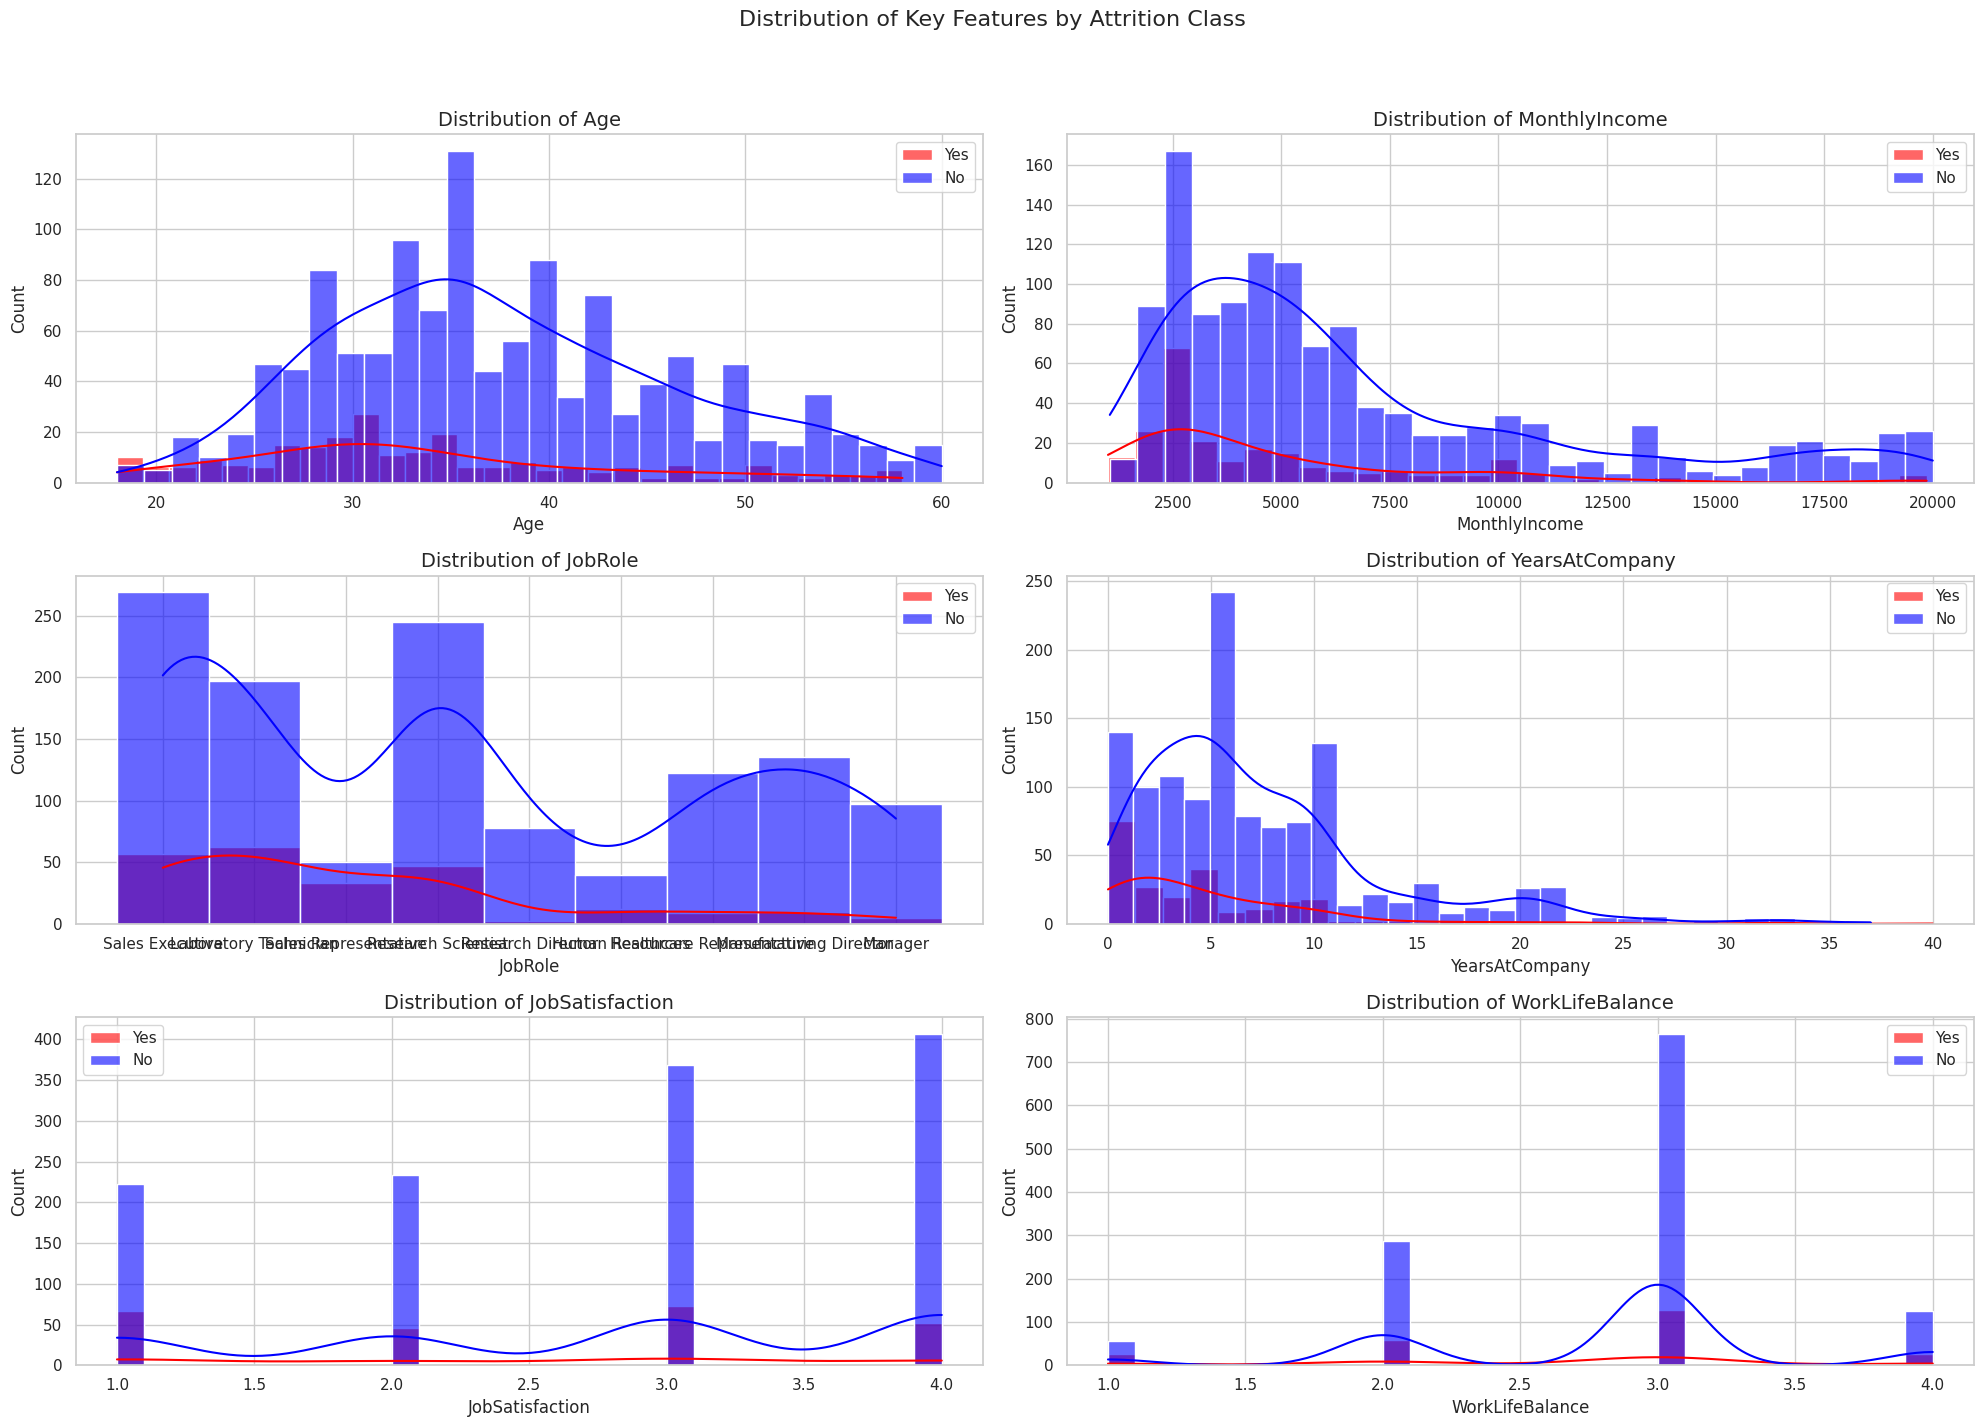

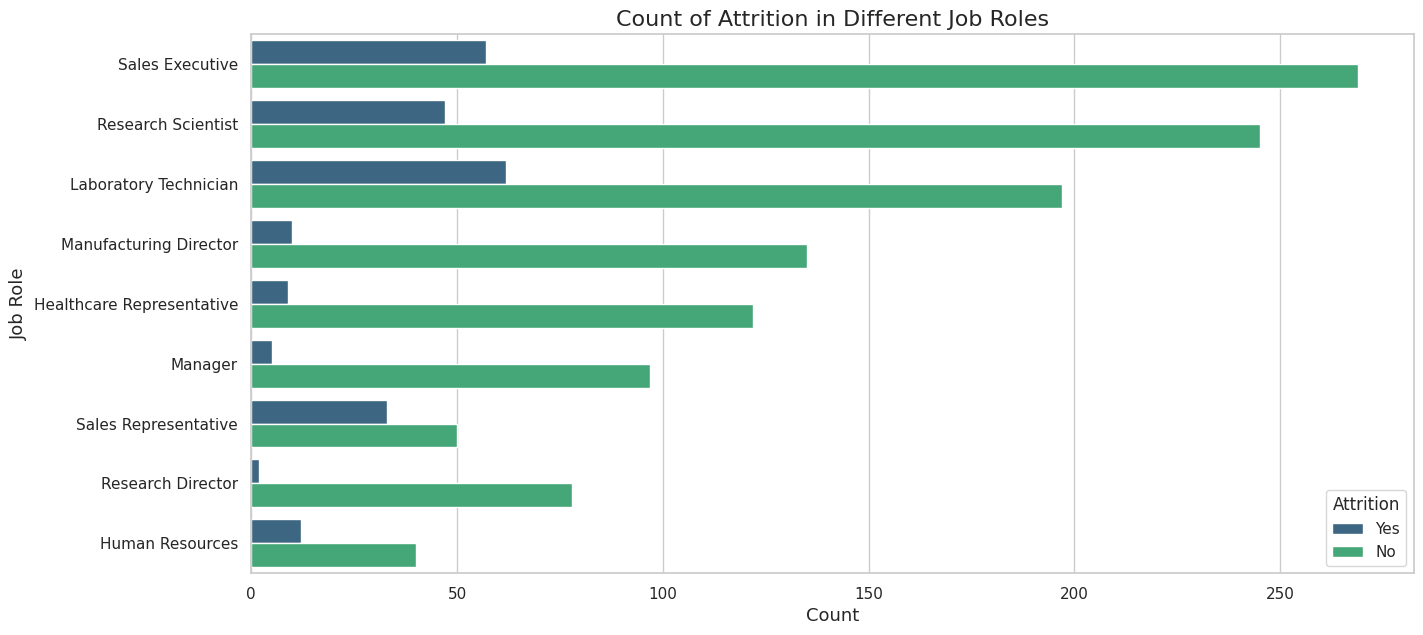

In [ ]:
# Create key features
key_features = ['Age', 'MonthlyIncome', 'JobRole', 'YearsAtCompany', 'JobSatisfaction', 'WorkLifeBalance', '']

attrition_yes = data[data['Attrition'] == 'Yes']
attrition_no = data[data['Attrition'] == 'No']

# Examine distribution
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle('Distribution of Key Features by Attrition Class', fontsize=16)

for ax, feature in zip(axes.ravel(), key_features):
    sns.histplot(attrition_yes[feature], bins=30, label='Yes', kde=True, color='red', ax=ax, alpha=0.6)
    sns.histplot(attrition_no[feature], bins=30, label='No', kde=True, color='blue', ax=ax, alpha=0.6)

    ax.set_title(f'Distribution of {feature}', fontsize=14)
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Had to adjust for categorical data (countplot) to make better sense
# Side note: Psychologists treat likert scale data like JobSat as interval data

plt.figure(figsize=(15, 7))
sns.countplot(data=data, y='JobRole', hue='Attrition', palette='viridis')
plt.title('Count of Attrition in Different Job Roles', fontsize=16)
plt.xlabel('Count', fontsize=13)
plt.ylabel('Job Role', fontsize=13)
plt.show()

In [ ]:
def pie_bar_plot(df, col, hue):
    plt.figure(figsize=(14, 6))

    # Extract value counts for the specified column
    value_counts = df[col].value_counts().sort_index()

    # First subplot: Pie chart
    plt.subplot(1, 2, 1)
    ax1 = value_counts
    plt.title(f"Distribution by {col}", fontweight="black", size=14, pad=15)
    colors = sns.color_palette('Set2', len(ax1))
    plt.pie(ax1.values, labels=ax1.index, autopct="%.1f%%", pctdistance=0.75, startangle=90,
            colors=colors, textprops={"size":14})
    center_circle = plt.Circle((0, 0), 0.4, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(center_circle)

    # Second subplot: Bar plot
    plt.subplot(1, 2, 2)
    new_df = df[df[hue] == 'Yes']
    value_1 = value_counts
    value_2 = new_df[col].value_counts().sort_index()  # Sort the values in the same order
    ax2 = np.floor((value_2 / value_1) * 100).values
    sns.barplot(x=value_2.index, y=value_2.values, palette='Set2')
    plt.title(f"Attrition Rate by {col}", fontweight="black", size=14, pad=15)
    for index, value in enumerate(value_2):
        plt.text(index, value, str(value) + " (" + str(int(ax2[index])) + "% )", ha="center", va="bottom", size=10)

    plt.tight_layout()
    plt.show()

**Analyzing Employee Attrition by Gender.**

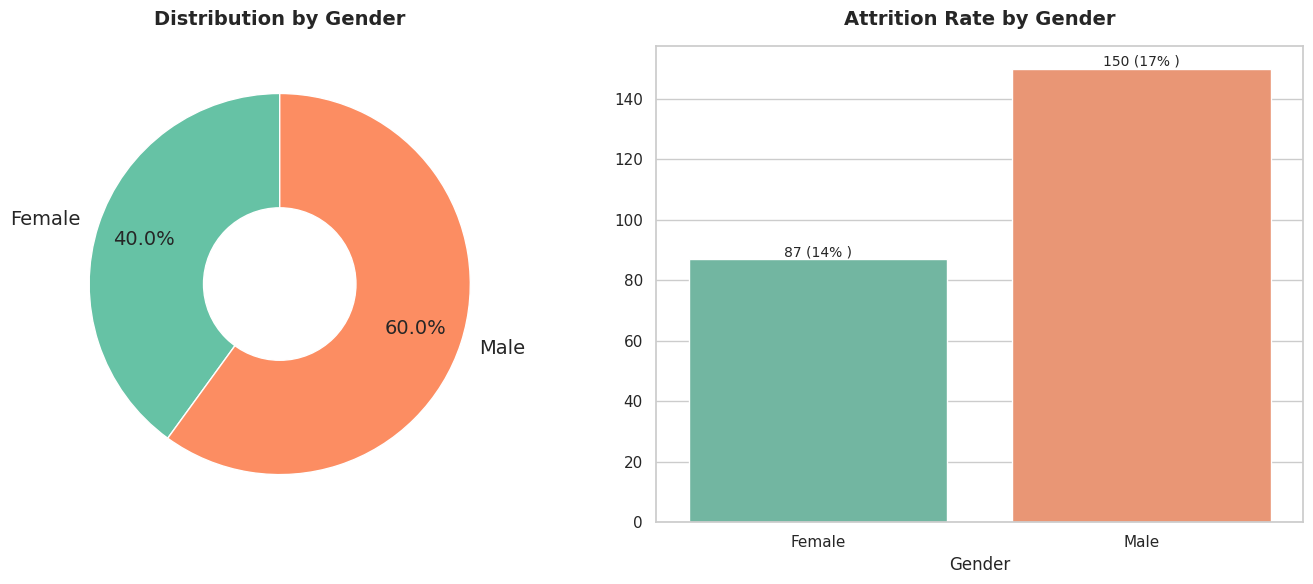

In [ ]:
pie_bar_plot(data, 'Gender', 'Attrition')

**Analyzing Employee Attrition by Marital Status**

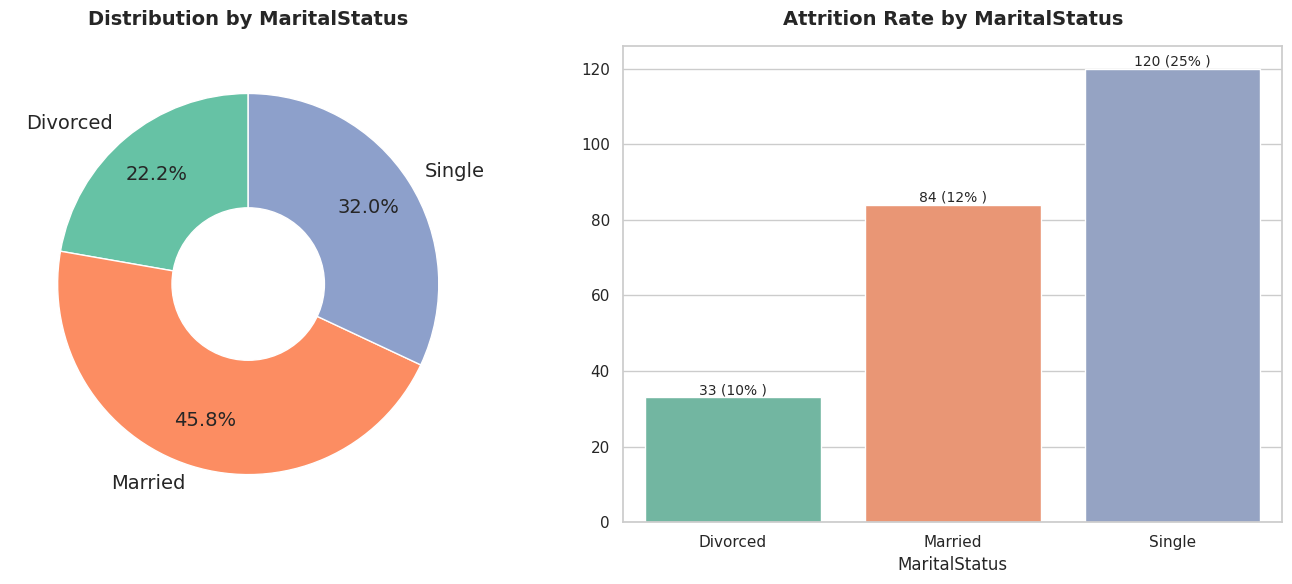

In [ ]:
pie_bar_plot(data, 'MaritalStatus', 'Attrition')

Analyzing Employee Attrition by Department.

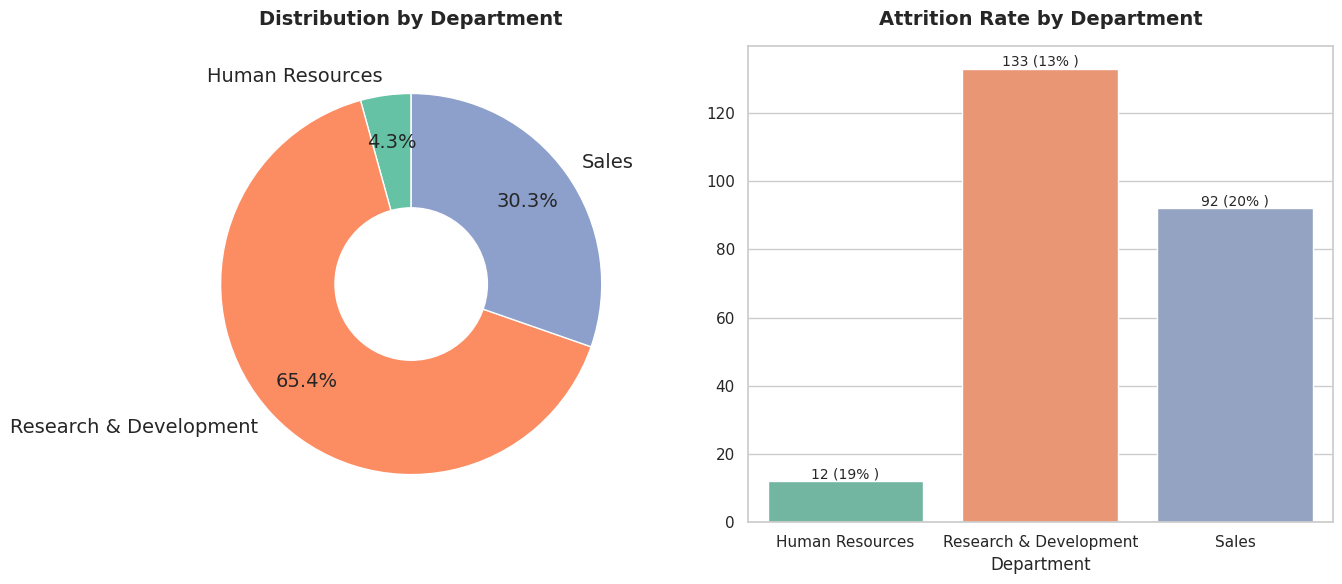

In [ ]:
pie_bar_plot(data, 'Department', 'Attrition')

**Analyzing Employee Attrition by Education.**
"Education": {"Below College": 1, "College": 2, "Bachelor": 3, "Master": 4, "Doctor": 5}



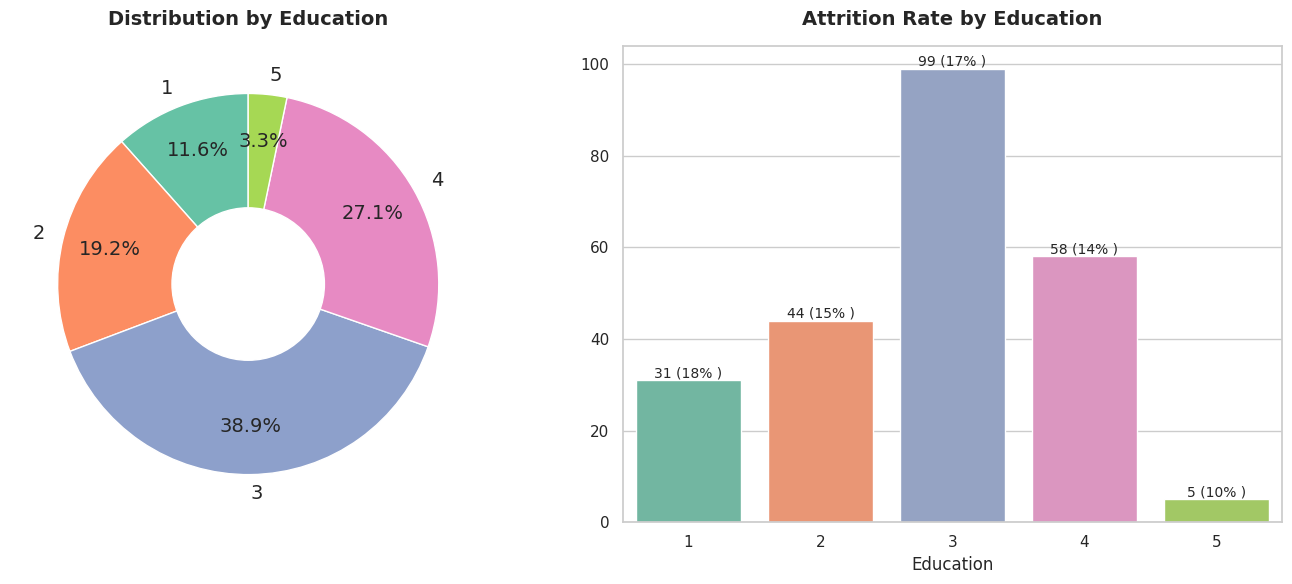

In [ ]:
pie_bar_plot(data, 'Education', 'Attrition')

**Employee Distribution by Age**

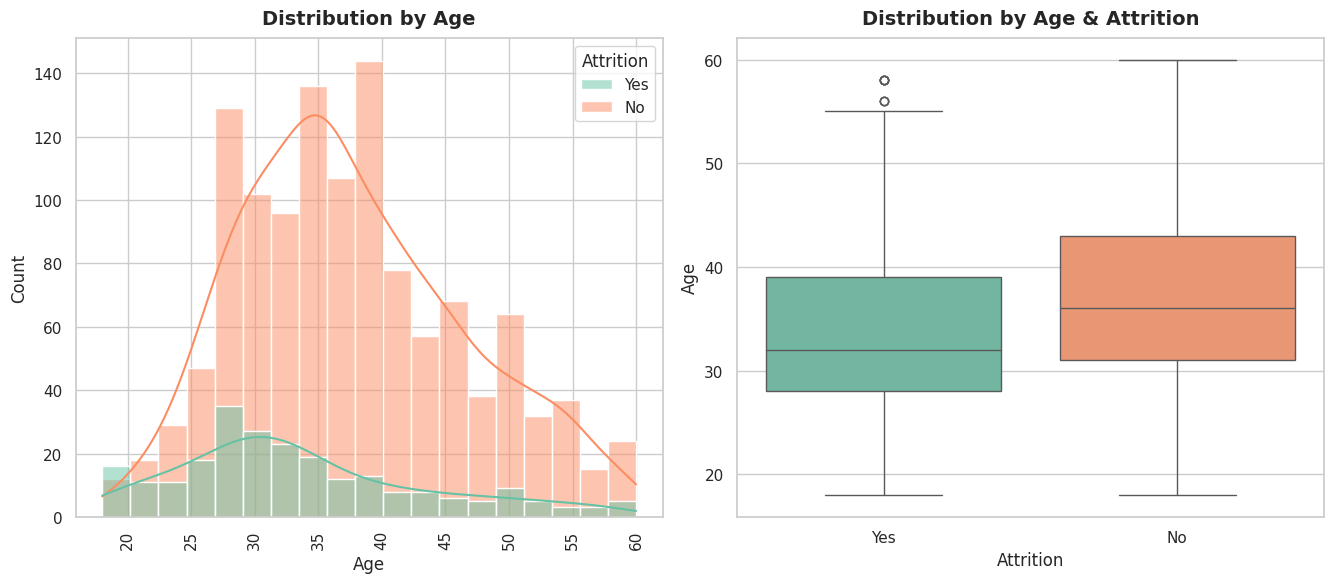

In [ ]:
!pip install matplotlib
# Import the necessary modules
import matplotlib.pyplot as plt
import seaborn as sns

# Define the hist_with_hue function
def hist_with_hue(df, col, hue):
    plt.figure(figsize=(13.5, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(x=col, hue=hue, data=df, kde=True, palette='Set2')

    # Configure the x-axis to display integer values and center-align the labels
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Use plt.MaxNLocator instead of ticker.MaxNLocator
    plt.xticks(rotation=90, position=(0.5, 0), ha='center')  # Rotate x-axis labels by 90 degrees and center-align

    plt.title(f"Distribution by {col}", fontweight="black", size=14, pad=10)

    plt.subplot(1, 2, 2)
    sns.boxplot(x=hue, y=col, data=df, palette='Set2')
    plt.title(f"Distribution by {col} & {hue}", fontweight="black", size=14, pad=10)
    plt.tight_layout()
    plt.show()

# Use the hist_with_hue function
hist_with_hue(data, 'Age', 'Attrition')


***Analyzing Employee Attrition by Education Field ***

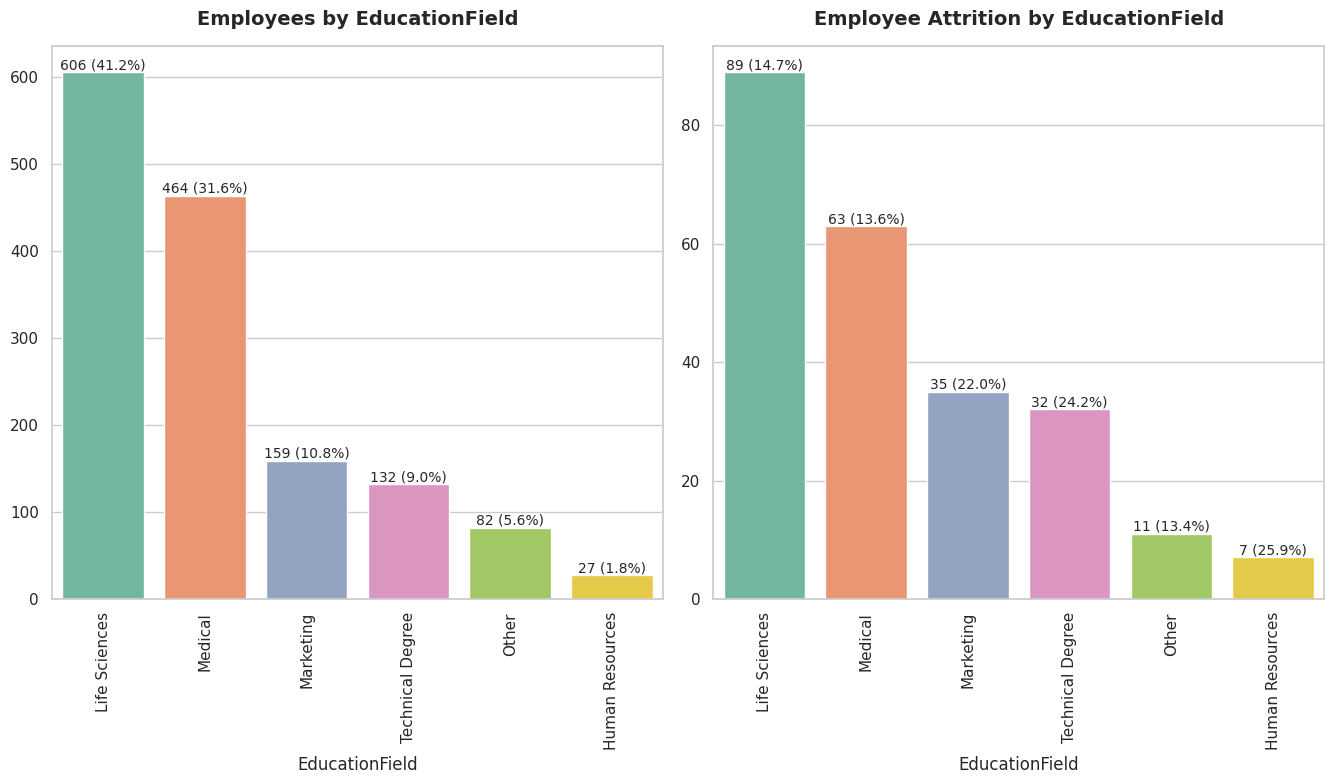

In [ ]:
def count_percent_plot(df, col, hue):

    plt.figure(figsize=(13.5, 8))
    plt.subplot(1, 2, 1)
    value_1 = df[col].value_counts()
    sns.barplot(x=value_1.index, y=value_1.values, order=value_1.index, palette='Set2')
    plt.title(f"Employees by {col}", fontweight="black", size=14, pad=15)
    for index, value in enumerate(value_1.values):
        count_percentage = "{:.1f}%".format((value / len(df)) * 100)
        plt.text(index, value, f"{value} ({count_percentage})", ha="center", va="bottom", size=10)
    plt.xticks(rotation=90)

    # Sort the values for the second subplot to match the order of the first subplot
    value_2 = df[df[hue] == 'Yes'][col].value_counts().reindex(value_1.index)

    plt.subplot(1, 2, 2)
    attrition_rate = (value_2 / value_1 * 100).values
    sns.barplot(x=value_2.index, y=value_2.values, order=value_1.index, palette='Set2')
    plt.title(f"Employee Attrition by {col}", fontweight="black", size=14, pad=15)
    for index, value in enumerate(value_2.values):
        attrition_percentage = "{:.1f}%".format(np.round(attrition_rate[index], 1))
        plt.text(index, value, f"{value} ({attrition_percentage})", ha="center", va="bottom", size=10)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

count_percent_plot(data, 'EducationField', 'Attrition')

Analyzing Employee Attrition by Years at Company.

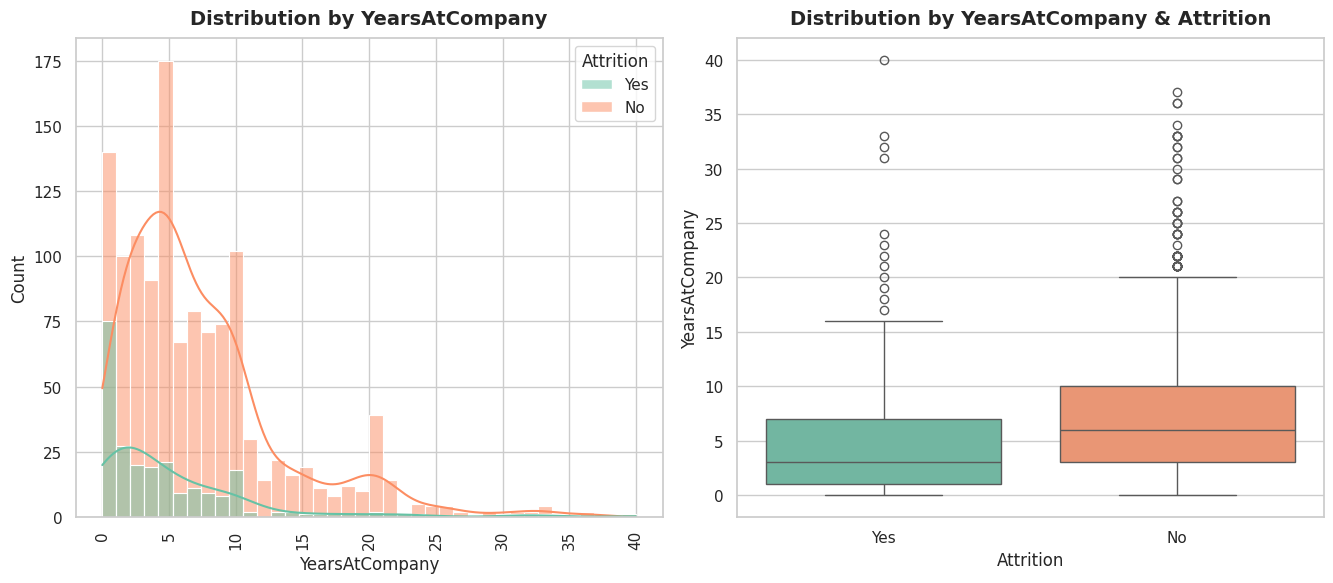

In [ ]:
hist_with_hue(data, 'YearsAtCompany', 'Attrition')

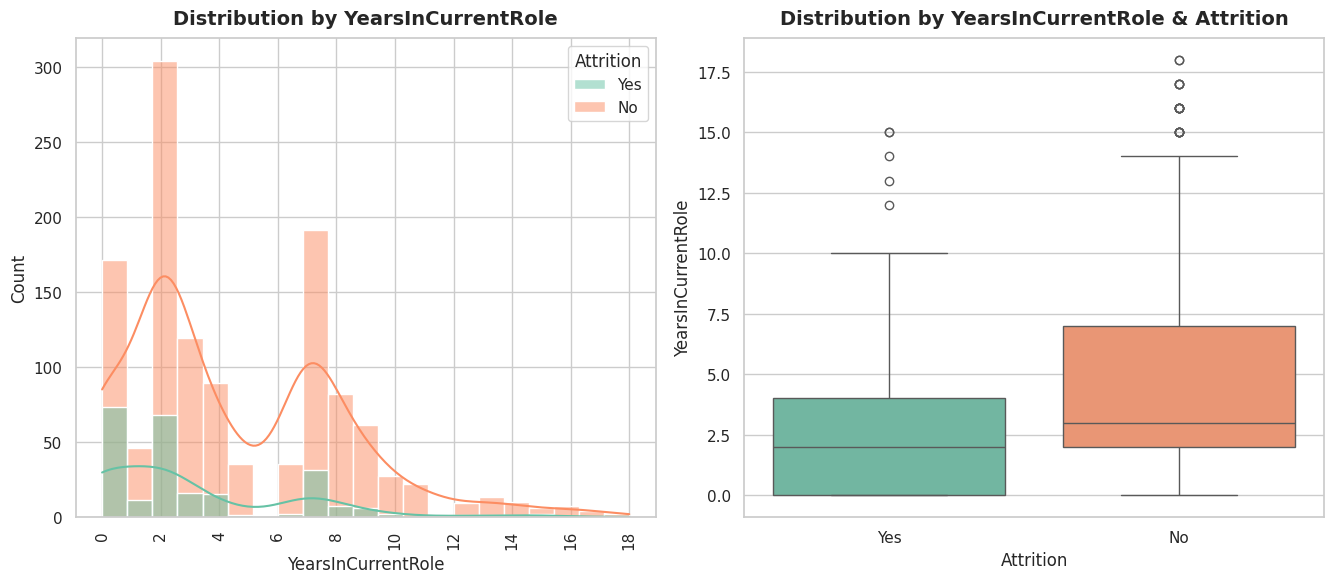

In [ ]:
hist_with_hue(data, 'YearsInCurrentRole', 'Attrition')

**Correlation Matrix**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
Attrition_le=LabelEncoder()
BusinessTravel_le=LabelEncoder()
Department_le=LabelEncoder()
Education_le=LabelEncoder()
EducationField_le=LabelEncoder()
EnvironmentSatisfaction_le=LabelEncoder()
Gender_le=LabelEncoder()
JobInvolvement_le=LabelEncoder()
JobRole_le=LabelEncoder()
JobSatisfaction_le=LabelEncoder()
MaritalStatus_le=LabelEncoder()
Over18_le=LabelEncoder()
OverTime_le=LabelEncoder()
PerformanceRating_le=LabelEncoder()
RelationshipSatisfaction_le=LabelEncoder()
WorkLifeBalance_le=LabelEncoder()

In [ ]:
data.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobSatisfaction,MaritalStatus,MonthlyIncome,OverTime,PercentSalaryHike,RelationshipSatisfaction,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole
0,41,Yes,Sales,1,2,Life Sciences,2,Female,94,3,...,4,Single,5993,Yes,11,1,8,1,6,4
1,49,No,Research & Development,8,1,Life Sciences,3,Male,61,2,...,2,Married,5130,No,23,4,10,3,10,7
2,37,Yes,Research & Development,2,2,Other,4,Male,92,2,...,3,Single,2090,Yes,15,2,7,3,0,0
3,33,No,Research & Development,3,4,Life Sciences,4,Female,56,3,...,3,Married,2909,Yes,11,3,8,3,8,7
4,27,No,Research & Development,2,1,Medical,1,Male,40,3,...,2,Married,3468,No,12,4,6,3,2,2


In [ ]:
data['Attrition'] = Attrition_le.fit_transform(data['Attrition'])
data['Department'] = Department_le.fit_transform(data['Department'])
data['Education'] = Education_le.fit_transform(data['Education'])
data['EducationField'] = EducationField_le.fit_transform(data['EducationField'])
data['EnvironmentSatisfaction'] = EnvironmentSatisfaction_le.fit_transform(data['EnvironmentSatisfaction'])
data['Gender'] = Gender_le.fit_transform(data['Gender'])
data['JobInvolvement'] = JobInvolvement_le.fit_transform(data['JobInvolvement'])
data['JobRole'] = JobRole_le.fit_transform(data['JobRole'])
data['JobSatisfaction'] = JobSatisfaction_le.fit_transform(data['JobSatisfaction'])
data['MaritalStatus'] = MaritalStatus_le.fit_transform(data['MaritalStatus'])
data['OverTime'] = OverTime_le.fit_transform(data['OverTime'])
data['RelationshipSatisfaction'] = RelationshipSatisfaction_le.fit_transform(data['RelationshipSatisfaction'])
data['WorkLifeBalance'] = WorkLifeBalance_le.fit_transform(data['WorkLifeBalance'])


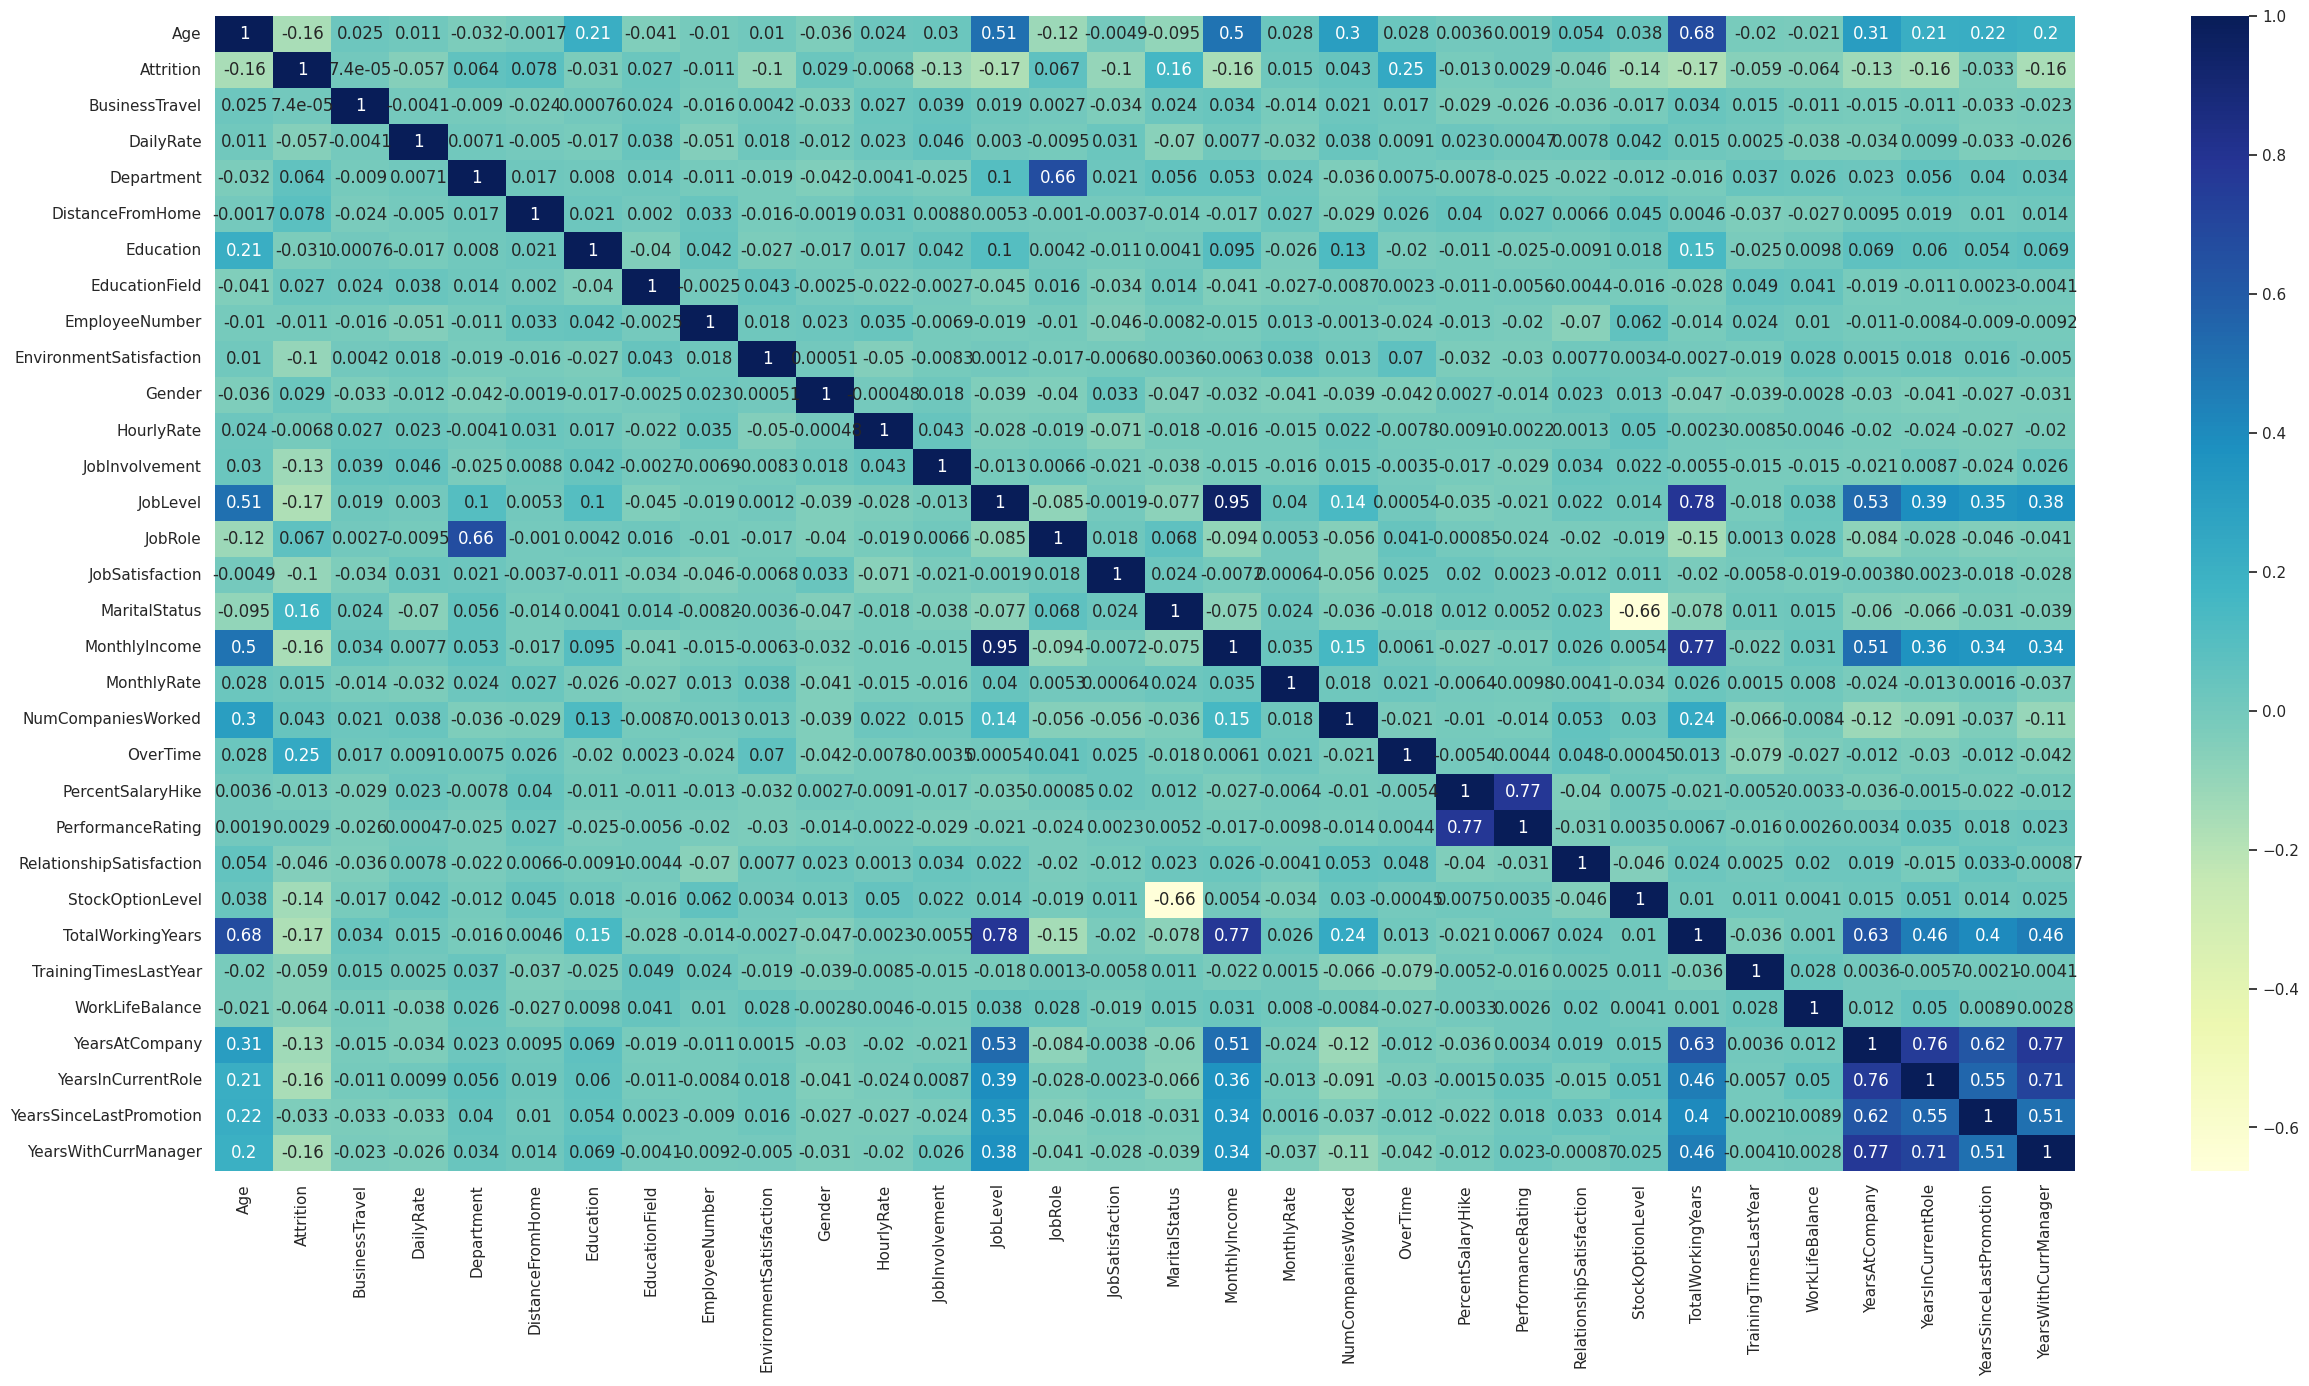

In [ ]:
plt.figure(figsize=(30, 15))
sns.heatmap(data_reduced.corr(), annot=True, cmap="YlGnBu")
plt.show()


In [ ]:
# droping columns which are highly correlated

cols = ["MonthlyIncome", "TotalWorkingYears", "YearsInCurrentRole", "PercentSalaryHike","YearsAtCompany"]
data.drop(columns=cols, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   Department                1470 non-null   int64
 3   DistanceFromHome          1470 non-null   int64
 4   Education                 1470 non-null   int64
 5   EducationField            1470 non-null   int64
 6   EnvironmentSatisfaction   1470 non-null   int64
 7   Gender                    1470 non-null   int64
 8   HourlyRate                1470 non-null   int64
 9   JobInvolvement            1470 non-null   int64
 10  JobRole                   1470 non-null   int64
 11  JobSatisfaction           1470 non-null   int64
 12  MaritalStatus             1470 non-null   int64
 13  OverTime                  1470 non-null   int64
 14  RelationshipSatisfaction  1470 non-null 

Check imbalance in dataset

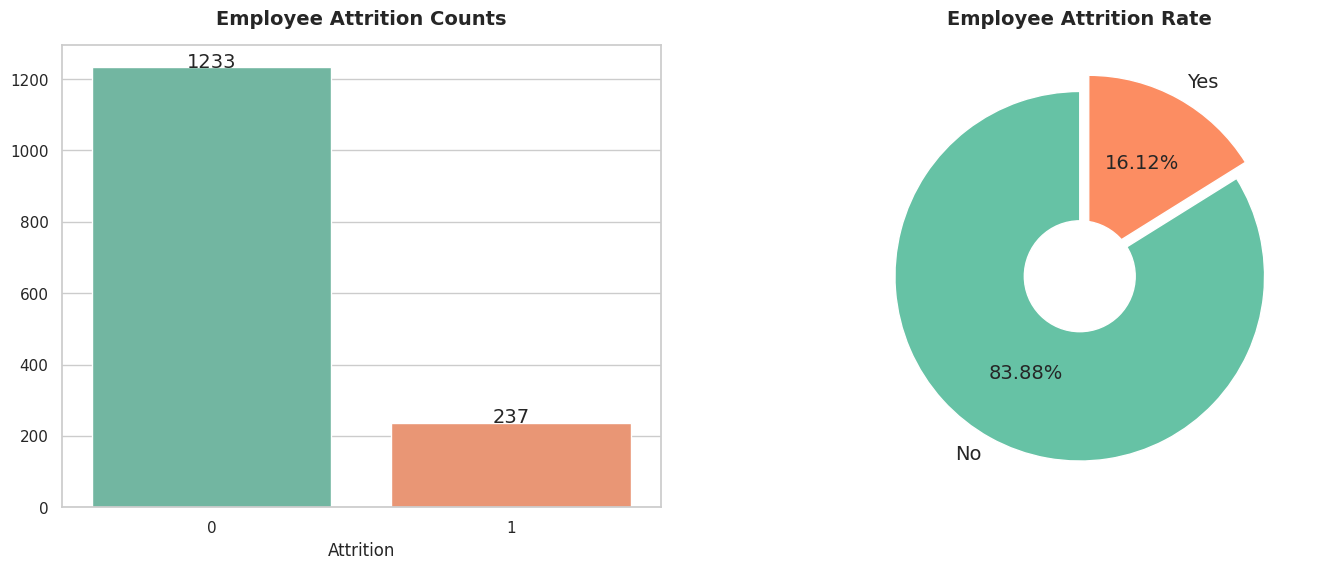

In [ ]:
#Visualization to show Employee Attrition in Counts.
plt.figure(figsize=(17,6))
plt.subplot(1,2,1)
attrition_rate = data["Attrition"].value_counts()
sns.barplot(x=attrition_rate.index,y=attrition_rate.values,palette= 'Set2')
plt.title("Employee Attrition Counts",fontweight="black", size=14, pad=15)
for i, v in enumerate(attrition_rate.values):
    plt.text(i, v, v,ha="center", fontsize=14)

#Visualization to show Employee Attrition in Percentage.
plt.subplot(1,2,2)
colors = sns.color_palette('Set2', len(attrition_rate))
plt.pie(attrition_rate, labels=["No","Yes"], autopct="%.2f%%", textprops={"size":14},
        colors = colors,explode=[0,0.1],startangle=90)
center_circle = plt.Circle((0, 0), 0.3, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)
plt.title("Employee Attrition Rate",fontweight="black",size=14 ,pad=15)
plt.show()

split dataa


In [ ]:
x = data.drop(['Attrition'], axis=1)
y = data[['Attrition']]

In [ ]:
x.head()


,Age,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobRole,JobSatisfaction,MaritalStatus,OverTime,RelationshipSatisfaction,WorkLifeBalance
0,41,2,1,1,1,1,0,94,2,7,3,2,1,0,0
1,49,1,8,0,1,2,1,61,1,6,1,1,0,3,2
2,37,1,2,1,4,3,1,92,1,2,2,2,1,1,2
3,33,1,3,3,1,3,0,56,2,6,2,1,1,2,2
4,27,1,2,0,3,0,1,40,2,2,1,1,0,3,2


In [ ]:
y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [ ]:
x = data.drop(['Attrition'], axis=1)
y = data[['Attrition']]

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size = 0.2, random_state = 43)
print(x_train.shape, x_test.shape)

(1176, 15) (294, 15)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_over)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5], y_train.head()

NameError: name 'X_over' is not defined

**balance data using SMOT**

In [ ]:
import imblearn
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_smote, y_smote = smote.fit_resample(x, y)
print(y.value_counts())
print()
print(y_smote.value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition
1    1233
0    1233
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()

In [ ]:
x_scaled = scaler.fit_transform(x_smote)
data_scaled = scaler.fit_transform(data)

In [ ]:
#Unscaled
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


(1972, 15) (1972,) (494, 15) (494,)


In [ ]:
#Scaled
x_train1, x_test1, y_train1, y_test1 = train_test_split(x_scaled, y_smote, test_size=0.2, random_state=42)
print(x_train1.shape, y_train1.shape, x_test1.shape, y_test1.shape)

(1972, 15) (1972,) (494, 15) (494,)


In [ ]:
#x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
#print(y_test.value_counts(normalize=True))  # Phải là 84% / 16%


In [ ]:
#from imblearn.over_sampling import SMOTE
#sm = SMOTE(random_state=42)
#x_train_smote, y_train_smote = sm.fit_resample(x_train, y_train)
#print(y_train_smote.value_counts())  # Phải là 50/50


In [ ]:
#scaler = StandardScaler()
#x_train_scaled = scaler.fit_transform(x_train_smote)
#x_test_scaled = scaler.transform(x_test)


Model bulding

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from scipy.stats import uniform
from sklearn import metrics
from sklearn.metrics import *

In [ ]:
training_score = []
testing_score = []
precission = []
recall = []
auc_score = []

In [ ]:
def model_prediction(model):
    model.fit(x_train,y_train)
    x_train_pred = model.predict(x_train)
    x_test_pred = model.predict(x_test)
    y_test_prob = model.predict_proba(x_test)[:, 1]
    a = accuracy_score(y_train,x_train_pred)*100
    b = accuracy_score(y_test,x_test_pred)*100
    c = precision_score(y_test,x_test_pred)
    d = recall_score(y_test,x_test_pred)
    e = roc_auc_score(y_test, y_test_prob)
    training_score.append(a)
    testing_score.append(b)
    precission.append(c)
    recall.append(d)
    auc_score.append(e)

    print(f"Accuracy_Score of {model} model on Training Data is:",a)
    print(f"Accuracy_Score of {model} model on Testing Data is:",b)
    print("\n------------------------------------------------------------------------")
    print(f"Precision Score of {model} model is:",c)
    print(f"Recall Score of {model} model is:",d)
    print(f"AUC Score of {model} model is:", e)
    print("\n------------------------------------------------------------------------")
    print(f"Classification Report of {model} model is:")
    print(classification_report(y_test, model.predict(x_test)))
    print("\n------------------------------------------------------------------------")
    print(f"Confusion Matrix of {model} model is:")
    cm = confusion_matrix(y_test,x_test_pred)
    plt.figure(figsize=(8,4))
    sns.heatmap(cm,annot=True,fmt="g",cmap="viridis")
    plt.show()
    print("\n------------------------------------------------------------------------")
    print(f"ROC - AUC Curve of {model} model is:")
    y_pred_proba = model.predict_proba(x_test)[:][:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)

    plt.figure(figsize=(8, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}",color="red")
    plt.plot([0, 1], [0, 1], linestyle="--", color="blue")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve",pad=20,fontweight="black")
    plt.legend()
    plt.show()

Random Forest

Accuracy_Score of RandomForestClassifier() model on Training Data is: 100.0
Accuracy_Score of RandomForestClassifier() model on Testing Data is: 85.03401360544217

------------------------------------------------------------------------
Precision Score of RandomForestClassifier() model is: 0.6363636363636364
Recall Score of RandomForestClassifier() model is: 0.14893617021276595
AUC Score of RandomForestClassifier() model is: 0.7666034972865879

------------------------------------------------------------------------
Classification Report of RandomForestClassifier() model is:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294


------------------------------------------------------------------------
Confusion Matrix 

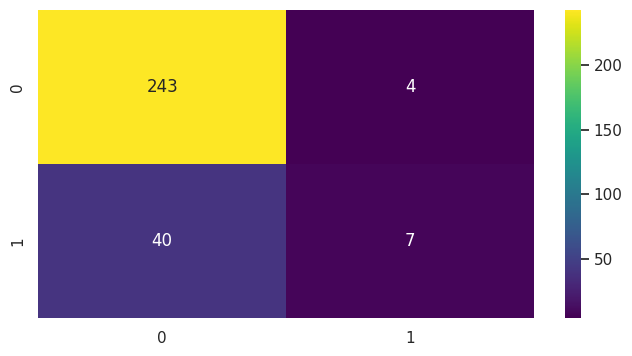


------------------------------------------------------------------------
ROC - AUC Curve of RandomForestClassifier() model is:


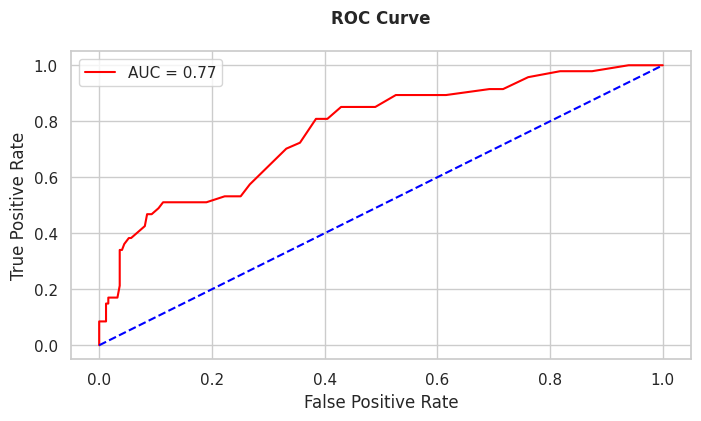

In [ ]:
model_prediction(RandomForestClassifier())


Gardient Boosting

Accuracy_Score of GradientBoostingClassifier() model on Training Data is: 92.77210884353741
Accuracy_Score of GradientBoostingClassifier() model on Testing Data is: 83.33333333333334

------------------------------------------------------------------------
Precision Score of GradientBoostingClassifier() model is: 0.45
Recall Score of GradientBoostingClassifier() model is: 0.19148936170212766
AUC Score of GradientBoostingClassifier() model is: 0.7858558015332932

------------------------------------------------------------------------
Classification Report of GradientBoostingClassifier() model is:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.45      0.19      0.27        47

    accuracy                           0.83       294
   macro avg       0.66      0.57      0.59       294
weighted avg       0.80      0.83      0.80       294


--------------------------------------------------------------------

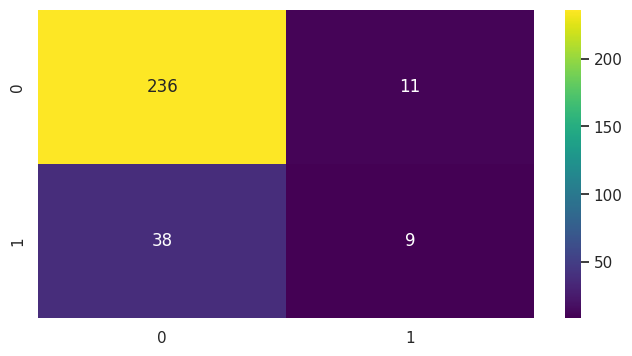


------------------------------------------------------------------------
ROC - AUC Curve of GradientBoostingClassifier() model is:


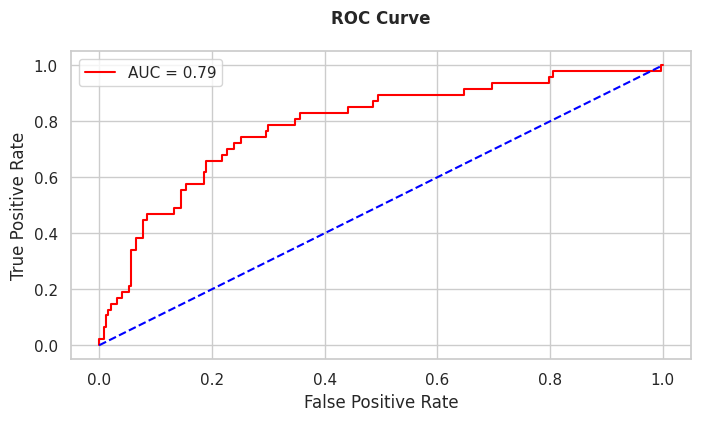

In [ ]:
model_prediction(GradientBoostingClassifier())

KNeighborsClassifier


Accuracy_Score of KNeighborsClassifier() model on Training Data is: 84.6938775510204
Accuracy_Score of KNeighborsClassifier() model on Testing Data is: 81.29251700680273

------------------------------------------------------------------------
Precision Score of KNeighborsClassifier() model is: 0.21428571428571427
Recall Score of KNeighborsClassifier() model is: 0.06382978723404255
AUC Score of KNeighborsClassifier() model is: 0.5406150400551296

------------------------------------------------------------------------
Classification Report of KNeighborsClassifier() model is:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       247
           1       0.21      0.06      0.10        47

    accuracy                           0.81       294
   macro avg       0.53      0.51      0.50       294
weighted avg       0.74      0.81      0.77       294


------------------------------------------------------------------------
Confusion Matrix 

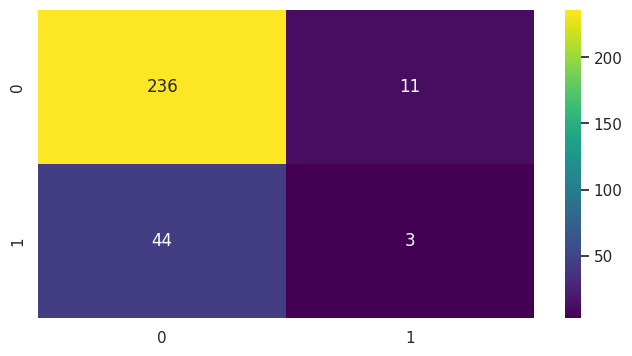


------------------------------------------------------------------------
ROC - AUC Curve of KNeighborsClassifier() model is:


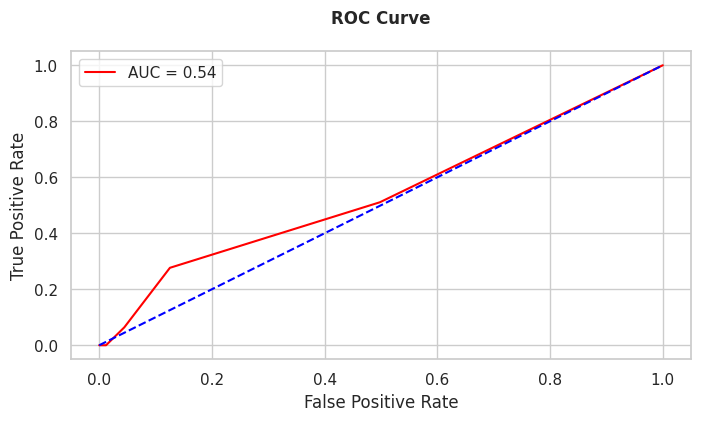

In [ ]:
model_prediction(KNeighborsClassifier())

Reult


In [ ]:
# Import thư viện
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Khởi tạo các mô hình con
rf = RandomForestClassifier(n_estimators=100, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01, random_state=42)

# Khởi tạo mô hình Stacking
base_models = [('rf', rf), ('knn', knn), ('gbc', gbc)]
meta_model = LogisticRegression()
stacking_ensemble = StackingClassifier(estimators=base_models, final_estimator=meta_model)

# Huấn luyện mô hình trên tập train
stacking_ensemble.fit(x_train1, y_train1)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('gbc',
                                GradientBoostingClassifier(learning_rate=0.01,
                                                           random_state=42))],
                   final_estimator=LogisticRegression())

Đánh giá trên tập TEST:
Accuracy: 0.8906882591093117
ROC AUC: 0.9544836065573771
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89       250
           1       0.87      0.91      0.89       244

    accuracy                           0.89       494
   macro avg       0.89      0.89      0.89       494
weighted avg       0.89      0.89      0.89       494



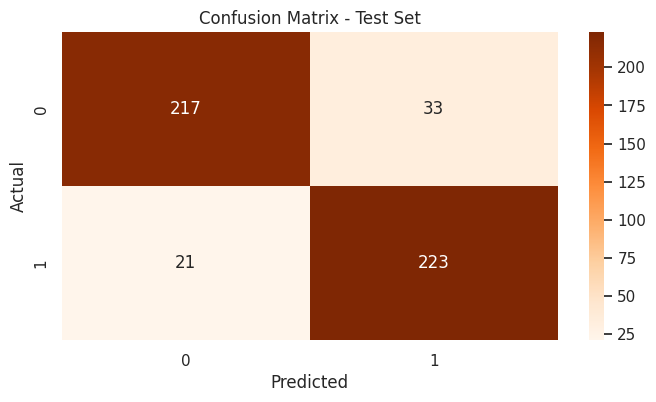

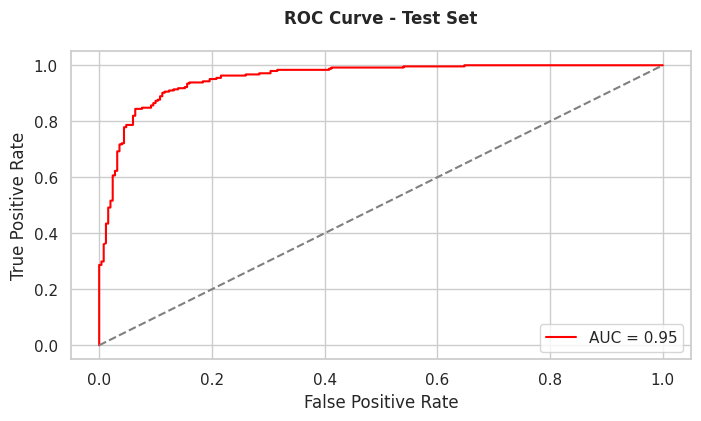

In [ ]:
# 1. Dự đoán trên tập test
y_pred_test = stacking_ensemble.predict(x_test1)
y_prob_test = stacking_ensemble.predict_proba(x_test1)[:, 1]

# 2. Đánh giá mô hình trên tập test
print("Đánh giá trên tập TEST:")
print("Accuracy:", accuracy_score(y_test1, y_pred_test))
print("ROC AUC:", roc_auc_score(y_test1, y_prob_test))
print("Classification Report:\n", classification_report(y_test1, y_pred_test))

# 3. Ma trận nhầm lẫn trên test
cm_test = confusion_matrix(y_test1, y_pred_test)
plt.figure(figsize=(8, 4))
sns.heatmap(cm_test, annot=True, fmt="g", cmap="Oranges")
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 4. ROC Curve trên test
fpr_test, tpr_test, _ = roc_curve(y_test1, y_prob_test)
auc_test = roc_auc_score(y_test1, y_prob_test)

plt.figure(figsize=(8, 4))
plt.plot(fpr_test, tpr_test, label=f"AUC = {auc_test:.2f}", color="red")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set", pad=20, fontweight="bold")
plt.legend()
plt.show()


In [ ]:
# Kiểm tra tỷ lệ trong dữ liệu gốc
print("Full data:")
print(data['Attrition'].value_counts(normalize=True))

# Nếu bạn có file test riêng
print("Test file data:")
print(y_test1['Attrition'].value_counts(normalize=True))



Full data:
Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64
Test file data:
Attrition
0    0.506073
1    0.493927
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# X: dữ liệu đặc trưng, y: nhãn Attrition (0/1)
X = data.drop(columns=["Attrition"])
y = data["Attrition"]

# Chia train/test và giữ nguyên phân bố nhãn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kết quả
print(y_test.value_counts(normalize=True))  # Kiểm tra lại phân bố


Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64


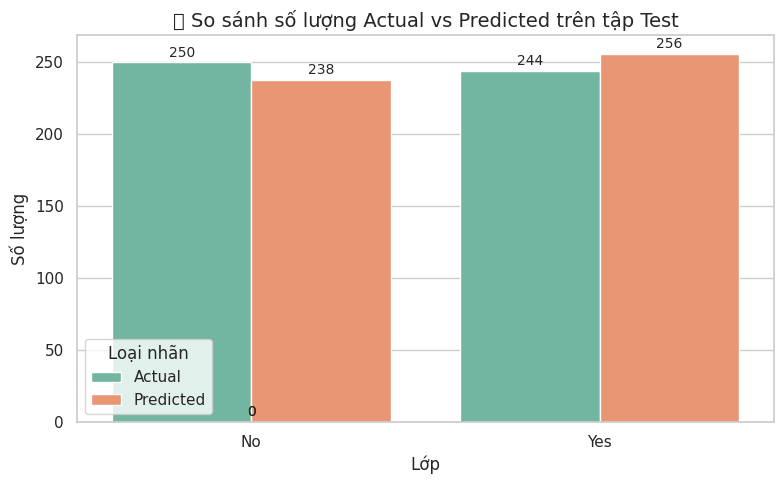

In [ ]:
# 5. Biểu đồ cột so sánh Actual vs Predicted
import pandas as pd

# Tạo DataFrame từ actual và predicted
df_compare = pd.DataFrame({
    # Access the 'Attrition' column and then its values as a NumPy array before raveling
    'Actual': y_test1['Attrition'].values.ravel(),
    'Predicted': y_pred_test
})

# Đếm số lượng từng lớp trong Actual and Predicted
actual_counts = df_compare['Actual'].value_counts().sort_index()
pred_counts = df_compare['Predicted'].value_counts().sort_index()

# Tạo DataFrame mới để vẽ
df_plot = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': pred_counts
}).reset_index().rename(columns={'index': 'Class'})

# Nếu nhãn là 0 và 1, bạn có thể ánh xạ chúng thành 'No' và 'Yes'
df_plot['Class'] = df_plot['Class'].map({0: 'No', 1: 'Yes'})

# Chuyển dữ liệu sang dạng long-form để vẽ seaborn
df_melted = df_plot.melt(id_vars='Class', var_name='Type', value_name='Count')

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
barplot = sns.barplot(data=df_melted, x='Class', y='Count', hue='Type', palette='Set2')

# Thêm số lượng trên mỗi cột
for p in barplot.patches:
    barplot.annotate(format(int(p.get_height()), ','),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 7), textcoords='offset points',
                     fontsize=10)

plt.title("📊 So sánh số lượng Actual vs Predicted trên tập Test", fontsize=14)
plt.xlabel("Lớp")
plt.ylabel("Số lượng")
plt.legend(title="Loại nhãn")
plt.tight_layout()
plt.show()